#ANALISIS EXPLORATORIO DE DATOS ALMACEN NANITOS

##Alumnos: Yibely Estefany Herrera Velasquez y Néstor Fabian Hidalgo González


#INTRODUCCIÓN
En este proyecto se realiza un analis sobre una base de ventas de un almacen de ropa y accesorios para Bebes. con base en esta información se busca identificar los días y horas de mayor afluencia de público con el fin de implementar estrategias que den una mayor percepción del servicio a los clientes.

## Origen de los datos
Los datos provienen del sistema de ventas de la tienda Nanitos, esta base de datos contine información del último trimestre de 2026, contiene un total de 3.709 registros.
###
ruta del archivo url: https://github.com/nhidalgog/PAD_Entrega_activiad_5_YH_y_NH/blob/main/reporte_de_ventas_nanitos_may_a_jul_2026.csv

##Importar librerias

In [ ]:
#En este notebook se va a trabajar con las siguientes librerías.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Carga de Datos

In [ ]:
url = "https://raw.githubusercontent.com/nhidalgog/PAD_Entrega_activiad_5_YH_y_NH/main/reporte_de_ventas_nanitos_may_a_jul_2026.csv"
reporte_de_ventas_nanitos_may_a_jul_2026 = pd.read_csv(url, encoding='latin1', delimiter=';')
reporte_de_ventas_nanitos_may_a_jul_2026.shape

El archivo de analisis contiene 3.708 filas y 16 columnas

##Validar carga de archivo y mostrar las primeras 5 filas

In [ ]:
reporte_de_ventas_nanitos_may_a_jul_2026.head()

##Validación de diagnóstico y Calidad

In [ ]:
# A continuación, se muestra los nombres de las columnas que tiene el archivo de ventas
reporte_de_ventas_nanitos_may_a_jul_2026.columns.tolist()

In [ ]:
# validación tipos de datos que identificó pandas
reporte_de_ventas_nanitos_may_a_jul_2026.dtypes.head(17)

In [ ]:
# validación de datos ausentes o nulos y/o duplicados
print(reporte_de_ventas_nanitos_may_a_jul_2026.isna().sum().sum())
print(reporte_de_ventas_nanitos_may_a_jul_2026.duplicated().sum())

En el resultado anterior se puede observar que el archivo contiene 1864 registros nulos y no se encuentran duplicados

Ahora vamos a hacer una copia del dataframe para usar un nombre más corto.

In [ ]:
data = reporte_de_ventas_nanitos_may_a_jul_2026.copy()
data.shape


Ahora vamos anormalizar los nombres de las columnas dejandolas todas en minusccula y reemplazando los espcios por "_"

In [ ]:
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')
data.columns

Ahora vamos a filtrar las columnas que se requieren pasando de 16 a 15 columnas, se suprime el "Nro. Documento"

In [ ]:
columnas = ['nro._factura', 'día', 'fecha', 'hora', 'cajero', 'vendedor',
       'cliente', 'medio_de_pago', 'cod_de_artículo',
       'producto', 'categoría', 'vr.costo', 'vr.unitario', 'cantidad_vendida',
       'total']

data = data[columnas]
data.shape

##Diagnóstico luego de la depuración inicial

In [ ]:
data.info()

In [85]:
# Cuántos faltantes tiene cada columna
faltantes = data.isna().sum()
faltantes[faltantes > 0]

,0
vendedor,1734


In [87]:
# Cuántos valores distintos hay en cada columna
data.nunique().head()

,0
nro_factura,2265
dia,7
fecha,92
hora,609
cajero,2


In [88]:
# Validación de cuántas filas están duplicadas
data.duplicated().sum()

np.int64(0)

Se observa que el archivo no contiene registros duplicados

In [89]:
#validación medios de pago
data['medio_de_pago'].value_counts(dropna=False)

,count
medio_de_pago,
Efectivo,1876
Nequi,1000
QR Bancolombia,370
Tarjeta Débito,198
Daviplata,136
Tarjeta crédito,124
Credito,4


De acuerdo con el anterior resultado se puede observar que el medío más utilizado es el efectivo con 1.876 transacciones, seguido de Nequi con 1.000 Trasacciones

In [ ]:
# Resumen numérico: aquí aparecen los valores imposibles
data[['medio_de_pago', 'producto', 'categoría', 'cantidad_vendida', 'total']].describe()

De acuerdo con el diagnóstico ejecutado se evidencia lo siguiente.

1. El campo vendedor tiene 1.734 valores nulos
2.   Todas las ventas están realizadas con el usuario vendedor1
3.   El medio de pago que más se utiliza es efectivo
4. Existen transacciones con valores negativos (cantidad y precio), esto se debe a posibles devoluciones o anulaciones

##TRANSFORMACIONES
En esta sección se realizarán transformaciones de tipos de datos, a los campos

*   'día' y 'medío_de_pago' de tipo 'object' a str
*   'fecha' y 'hora' de tipo objet a 'datetime'



Carga de datos y limpieza inicial
por temas de horario es mas facil para que queden en formato de 12 horas

In [90]:
'''
librería re: es el módulo estándar para trabajar con expresiones regulares (conocidas como regex).
Permite buscar, coincidir, extraer, reemplazar y manipular cadenas de texto mediante patrones de búsqueda, en esta transformación reemplaza "." por ","

librería unicodedata: La utilizamos para eliminar acentos (tildes ej. la columna categoría) y reemplazar los puntos en los nombres de las columnas por un "_"
#ejemplo "vr.costo" -> "vr_costo"

#Librería warnings: La utilizamos para validar advertencias en la ejecución sin que el programa se detenga. ejm librerías obsoletas
'''

import re
import unicodedata
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/nhidalgog/PAD_Entrega_activiad_5_YH_y_NH/main/reporte_de_ventas_nanitos_may_a_jul_2026.csv"

# Lectura tolerante: si el separador ';' no divide el archivo, se reintenta con ','
try:
    data = pd.read_csv(url, encoding='latin1', sep=';')
    if data.shape[1] == 1:
        data = pd.read_csv(url, encoding='latin1', sep=',')
except UnicodeDecodeError:
    data = pd.read_csv(url, encoding='utf-8', sep=';')


def normaliza(nombre):
    """minúsculas, sin tildes y sin signos: 'Vr.Costo' -> 'vr_costo'"""
    n = str(nombre).strip().lower()
    n = unicodedata.normalize('NFKD', n).encode('ascii', 'ignore').decode()
    return re.sub(r'[^a-z0-9]+', '_', n).strip('_')


data.columns = [normaliza(c) for c in data.columns]
print("Columnas del archivo:", list(data.columns))

# Se buscan las columnas por palabra clave en vez de por nombre exacto
ALIAS = {
    'nro_factura': ['factura'], 'dia': ['dia'], 'fecha': ['fecha'], 'hora': ['hora'],
    'cajero': ['cajero'], 'vendedor': ['vendedor'], 'cliente': ['cliente'],
    'medio_de_pago': ['pago'], 'cod_articulo': ['cod'], 'producto': ['producto'],
    'categoria': ['categoria'], 'vr_costo': ['costo'], 'vr_unitario': ['unitario'],
    'cantidad_vendida': ['cantidad'], 'total': ['total'],
}

renombres, faltantes = {}, []
for destino, claves in ALIAS.items():
    match = next((c for c in data.columns
                  if all(k in c for k in claves) and c not in renombres), None)
    if match:
        renombres[match] = destino
    else:
        faltantes.append(destino)

data = data.rename(columns=renombres)[list(renombres.values())]
if faltantes:
    print("Aviso: no se encontró equivalente para", faltantes)


def a_numero(serie):
    """Convierte montos en formato colombiano ('1.234,50', '$ 1.234') a float."""
    if pd.api.types.is_numeric_dtype(serie):
        return serie

    def conv(v):
        if pd.isna(v):
            return np.nan
        t = re.sub(r'[^\d,.\-]', '', str(v))
        if not t:
            return np.nan
        if ',' in t:                      # coma decimal -> el punto es de miles
            t = t.replace('.', '').replace(',', '.')
        elif re.search(r'\.\d{3}$', t):   # solo puntos y grupos de 3 -> miles
            t = t.replace('.', '')
        try:
            return float(t)
        except ValueError:
            return np.nan

    return serie.map(conv)


for col in ['vr_costo', 'vr_unitario', 'cantidad_vendida', 'total']:
    if col in data.columns:
        data[col] = a_numero(data[col])

print(f"\nTamaño del dataset: {data.shape}")
print("Tipos numéricos:", data[['vr_costo', 'vr_unitario', 'cantidad_vendida', 'total']].dtypes.to_dict())
nulos = data.isna().sum()
print(f"\nNulos por columna:\n{nulos[nulos > 0] if (nulos > 0).any() else 'sin nulos'}")
data.head()

Columnas del archivo: ['nro_factura', 'dia', 'fecha', 'hora', 'cajero', 'vendedor', 'nro_documento', 'cliente', 'medio_de_pago', 'cod_de_articulo', 'producto', 'categoria', 'vr_costo', 'vr_unitario', 'cantidad_vendida', 'total']

Tamaño del dataset: (3708, 15)
Tipos numéricos: {'vr_costo': dtype('int64'), 'vr_unitario': dtype('int64'), 'cantidad_vendida': dtype('float64'), 'total': dtype('int64')}

Nulos por columna:
vendedor    1734
dtype: int64


,nro_factura,dia,fecha,hora,cajero,vendedor,cliente,medio_de_pago,cod_articulo,producto,categoria,vr_costo,vr_unitario,cantidad_vendida,total
0,53257,viernes,31 de julio de 2026,8:06 p. m.,cajero 1,Vendedor,Ventas Mostrador,Efectivo,1420,MEDIAS ENCAJE MARATHON,ROPA,8500,14500,1.0,14500
1,53256,viernes,31 de julio de 2026,7:59 p. m.,cajero 1,Vendedor,Ventas Mostrador,Efectivo,3070-2,ROPA INTERIOR NIÑA X 3,ROPA,9000,17000,1.0,17000
2,53255,viernes,31 de julio de 2026,7:57 p. m.,cajero 1,Vendedor,Ventas Mostrador,Efectivo,2080-1,BODY BLANCO X UNIDAD,ROPA,5000,10000,1.0,10000
3,53255,viernes,31 de julio de 2026,7:57 p. m.,cajero 1,Vendedor,Ventas Mostrador,Efectivo,1943-1,BODY SUNNOZY X UNIDAD,ROPA,10125,17000,1.0,17000
4,53254,viernes,31 de julio de 2026,7:55 p. m.,cajero 1,Vendedor,Ventas Mostrador,Efectivo,1998-1,CONJUNTO DE LANA IMPORTADO,ROPA,55000,90000,1.0,90000


In [91]:
# 2. Transformación de Fechas y Horas, conversión del mes de texto a número
MESES = {'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
         'julio': 7, 'agosto': 8, 'septiembre': 9, 'setiembre': 9, 'octubre': 10,
         'noviembre': 11, 'diciembre': 12}
NOMBRES_MES = {v: k.capitalize() for k, v in MESES.items() if k != 'setiembre'}


def a_fecha(serie):
    """Acepta '12 de mayo de 2026' y también 12/05/2026 o 2026-05-12."""
    t = (serie.astype(str).str.lower()
         .map(lambda s: unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode())
         .str.replace(r'\bde\b', ' ', regex=True)
         .str.replace(r'\s+', ' ', regex=True).str.strip())
    for nombre, num in MESES.items():
        t = t.str.replace(nombre, f'{num:02d}', regex=False)

    fechas = pd.to_datetime(t, format='%d %m %Y', errors='coerce')
    pendientes = fechas.isna() & serie.notna()
    if pendientes.any():
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fechas[pendientes] = pd.to_datetime(serie[pendientes], errors='coerce', dayfirst=True)
    return fechas


def a_hora(serie):
    """Acepta '1:05 p. m.', '01:05 PM', '13:05' y '13:05:00'."""
    t = (serie.astype(str).str.lower()
         .str.replace('.', '', regex=False)
         .str.replace(r'\s+', '', regex=True)
         .str.replace('am', ' AM', regex=False)
         .str.replace('pm', ' PM', regex=False).str.strip())

    horas = pd.Series(pd.NaT, index=serie.index, dtype='datetime64[ns]')
    for fmt in ['%I:%M %p', '%I:%M:%S %p', '%H:%M', '%H:%M:%S']:
        pendientes = horas.isna()
        if not pendientes.any():
            break
        horas[pendientes] = pd.to_datetime(t[pendientes], format=fmt, errors='coerce')
    return horas


data['fecha'] = a_fecha(data['fecha'])
data['hora_dt'] = a_hora(data['hora'])          # se conserva la columna 'hora' original

data['mes_num'] = data['fecha'].dt.month
data['mes'] = data['mes_num'].map(NOMBRES_MES)  # sin locale: funciona en Windows, Mac y Colab
data['hora_del_dia'] = data['hora_dt'].dt.hour

orden_meses = [NOMBRES_MES[m] for m in sorted(data['mes_num'].dropna().unique())]
data['mes'] = pd.Categorical(data['mes'], categories=orden_meses, ordered=True)

print(f"Fechas no reconocidas: {data['fecha'].isna().sum()} | Horas no reconocidas: {data['hora_dt'].isna().sum()}")
data[['fecha', 'hora', 'hora_dt', 'mes', 'hora_del_dia']].head()

Fechas no reconocidas: 0 | Horas no reconocidas: 0


,fecha,hora,hora_dt,mes,hora_del_dia
0,2026-07-31,8:06 p. m.,1900-01-01 20:06:00,Julio,20
1,2026-07-31,7:59 p. m.,1900-01-01 19:59:00,Julio,19
2,2026-07-31,7:57 p. m.,1900-01-01 19:57:00,Julio,19
3,2026-07-31,7:57 p. m.,1900-01-01 19:57:00,Julio,19
4,2026-07-31,7:55 p. m.,1900-01-01 19:55:00,Julio,19


In [92]:
# Rango cubierto por los datos
print(data['fecha'].min())
print(data['fecha'].max())

2026-05-01 00:00:00
2026-07-31 00:00:00


Como se puede observar se realizó la transformación de los tipos de datos mencionados, donde se observa que la fecha inicial del reporte es 01may2026 y la fecha fin es 31jul2026

#INDICADORES DE DESEMPEÑO NANITOS
## En esta sección vamos a ver el analisis de datos en tablas de resumen y graficos

In [94]:
#En este primer analisis vamos a generar un resumen de las ventas totales por cada mes
import pandas as pd

##Ventas Mensuales
# Crear la columna 'mes' usando el número del mes y mapeándolo
data['mes_num'] = data['fecha'].dt.month
data['mes'] = data['mes_num'].map(NOMBRES_MES)

# Evolución mensual de las ventas
vmensuales = data.groupby('mes')['total'].sum().round(2)

# Asegurar que los meses estén en orden cronológico para la visualización
# Obtener meses únicos y ordenarlos según su número de mes
# Primero, creamos un DataFrame temporal para asegurar el orden correcto de los meses
meses_ordenados_df = data[['mes_num', 'mes']].drop_duplicates().sort_values('mes_num')
orden_meses = meses_ordenados_df['mes'].tolist()
vmensuales = vmensuales.reindex(orden_meses)

display(vmensuales)

,total
mes,
Mayo,39217640
Junio,42289849
Julio,46103046


El anterior resultado nos muestra el resumen de ventas ordenado por mes donde Julio es el mes de mayor volumen de ventas.

## Calculo la Ganancia por Transacción

Aquí definimos una función que calcula la ganancia de cada venta, usando el precio unitario (`vr.unitario`) y el costo unitario (`vr.costo`), multiplicado por la cantidad vendida.

In [95]:
import pandas as pd

# Aplicar la función para calcular el costo total de cada transacción
data['costo_total'] = data['vr_costo'] * data['cantidad_vendida']

# Calcular la ganancia para cada transacción usando la sugerencia del usuario
data['ganancia_transaccion'] = data['total'] - data['costo_total']

# Mostrar las primeras filas con las nuevas columnas para verificación
display(data[['vr_unitario', 'vr_costo', 'cantidad_vendida', 'total', 'costo_total', 'ganancia_transaccion']].head())

,vr_unitario,vr_costo,cantidad_vendida,total,costo_total,ganancia_transaccion
0,14500,8500,1.0,14500,8500.0,6000.0
1,17000,9000,1.0,17000,9000.0,8000.0
2,10000,5000,1.0,10000,5000.0,5000.0
3,17000,10125,1.0,17000,10125.0,6875.0
4,90000,55000,1.0,90000,55000.0,35000.0


La anterior tabla nos muestra el resultado de la ganancia por cada venta realizada

## Total por Mes: Costo, Ventas y Ganancia

Ahora, agruparemos los datos por mes para obtener el costo total y la ganancia total en una única tabla, junto con las ventas.

In [96]:
# Cálculos Financieros y Desempeño
data['costo_total'] = data['vr_costo'] * data['cantidad_vendida']
data['ganancia_transaccion'] = data['total'] - data['costo_total']

resumen_mensual = (data.dropna(subset=['mes'])
                   .groupby('mes', observed=True)
                   .agg(ventas_totales=('total', 'sum'),
                        costo_total=('costo_total', 'sum'),
                        ganancia_total=('ganancia_transaccion', 'sum'),
                        transacciones=('total', 'size')))
resumen_mensual['margen_%'] = (resumen_mensual['ganancia_total'] /
                               resumen_mensual['ventas_totales'] * 100).round(1)

display(resumen_mensual)

,ventas_totales,costo_total,ganancia_total,transacciones,margen_%
mes,,,,,
Julio,46103046,28067806.0,18035240.0,1291,39.1
Junio,42289849,26290506.0,15999343.0,1254,37.8
Mayo,39217640,24313623.0,14904017.0,1163,38.0


De acuerdo al anterior resultado se puede observar que Julio fue el mes con mayor ventas con un 39.1 de margen y 1.291 transacciones generadas.

In [97]:
# Informe agrupado por mes sumando el total de ventas, costo_total y ganancia_transaccion
resumen_mensual_costo_ganancia = data.groupby('mes').agg(
    ventas_totales=('total', 'sum'),
    costo_total=('costo_total', 'sum'),
    ganancia_total=('ganancia_transaccion', 'sum')
).round(2)

# Reindexar para asegurar el orden cronológico de los meses
# Usamos el mismo 'orden_meses' que se generó para vmensuales
resumen_mensual_costo_ganancia = resumen_mensual_costo_ganancia.reindex(orden_meses)

display(resumen_mensual_costo_ganancia)

,ventas_totales,costo_total,ganancia_total
mes,,,
Mayo,39217640,24313623.0,14904017.0
Junio,42289849,26290506.0,15999343.0
Julio,46103046,28067806.0,18035240.0


### Ventas, Costo y Ganancia Mensual por Categoría

Vamos a desglosar las ventas, el costo y la ganancia por cada categoría de producto, agrupadas por mes y ordenadas por la ganancia total de mayor a menor.

In [98]:
# Agrupar por mes y categoría, y sumar el total, costo_total y ganancia_transaccion
resumen_mensual_categoria = data.groupby(['mes', 'categoria']).agg(
    ventas_totales=('total', 'sum'),
    costo_total=('costo_total', 'sum'),
    ganancia_total=('ganancia_transaccion', 'sum')
).round(2)

# Reindexar para asegurar el orden cronológico de los meses, manteniendo la categoría
# Convertir el DataFrame a MultiIndex para reindexar correctamente si 'mes' es parte del índice
if isinstance(resumen_mensual_categoria.index, pd.MultiIndex):
    resumen_mensual_categoria = resumen_mensual_categoria.reindex(pd.MultiIndex.from_product([orden_meses, resumen_mensual_categoria.index.get_level_values('categoria').unique()], names=['mes', 'categoria']))
else:
    # Si 'mes' no está en el índice (lo cual es poco probable aquí), no se reindexa
    pass # Se asume que 'mes' es el primer nivel del MultiIndex

# Eliminar filas donde no hay datos para una combinación mes-categoría específica
resumen_mensual_categoria = resumen_mensual_categoria.dropna()

# Ordenar el resultado por ganancia_total de mayor a menor
resumen_mensual_categoria_sorted = resumen_mensual_categoria.sort_values(by='ganancia_total', ascending=False)

display(resumen_mensual_categoria_sorted)

,,ventas_totales,costo_total,ganancia_total
mes,categoria,,,
Julio,ROPA,21153415.0,11213114.0,9940301.0
Junio,ROPA,18104531.0,9474032.0,8630499.0
Mayo,ROPA,16323547.0,8538007.0,7785540.0
Junio,ACCESORIOS,4115628.0,2196335.0,1919293.0
Julio,ACCESORIOS,4058497.0,2190222.0,1868275.0
...,...,...,...,...
Mayo,BAUTIZO,25500.0,15000.0,10500.0
Junio,BAUTIZO,17000.0,10000.0,7000.0
Julio,BAUTIZO,8500.0,2500.0,6000.0


Del resultado anterior podemos observar que la categoría de mayor venta y utilidades es la de "ROPA", esta lidera en ventas en los tres meses analizados

### Top 5 de Categorías con Mayor Ganancia en Mayo

In [99]:
# Get the top 5 categories with the highest profit for May
# resumen_mensual_categoria_sorted is already sorted by ganancia_total descending
top_5_mayo = resumen_mensual_categoria_sorted.loc['Mayo'].head(5)

# Ordenar el top 5 de mayo por ventas_totales de mayor a menor
top_5_mayo_sorted_by_ventas = top_5_mayo.sort_values(by='ventas_totales', ascending=False)
display(top_5_mayo_sorted_by_ventas)

,ventas_totales,costo_total,ganancia_total
categoria,,,
ROPA,16323547.0,8538007.0,7785540.0
PAÑAL,8245635.0,7352709.0,892926.0
ASEO,3611634.0,2617277.0,994357.0
ACCESORIOS,3146114.0,1591831.0,1554283.0
CALZADO,1715500.0,777000.0,938500.0


Las categorias pcon mayor ganancia en el mes de mayo fueron "ROPA", PAÑAL, "ASEO", "ACCESORIOS" y "CALZADO"

## Ventas Diarias

Ahora, calcularemos la suma total de las ventas por cada día para identificar patrones diarios.

In [100]:
# Evolución valor de las ventas
vdiarias = data.groupby('fecha')['total'].sum().round(2)
display(vdiarias)

,total
fecha,
2026-05-01,2887494
2026-05-02,1995236
2026-05-03,1588058
2026-05-04,642115
2026-05-05,442756
...,...
2026-07-27,1168412
2026-07-28,712726
2026-07-29,151865


Se observa que los días con mayor ventas son fines de semana y días de quincena

###REPORTES - VISUALIZACIÓN

##A continuación se muestra en graficas el valor de las ventas del trimestre agrupado por categoria

In [101]:
ingreso_categoria = data.groupby('categoria')['total'].sum().sort_values()
ingreso_categoria.head(10)

,total
categoria,
BAUTIZO,51000
ADAPTADORES,76960
SOCIEDAD CL-MF,98000
VALETA - BALETA,135000
CORRALES,279464
JUGUETES,291080
LACTANCIA,410084
PISCINA,436968
BAÑERAS,599885


Acontinuación se muestra el gráfico de las ventas por categoría durante el trimestre (mayo a julio)

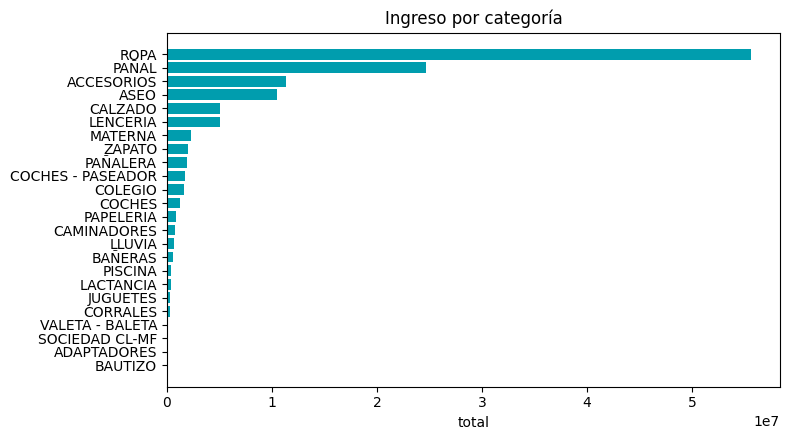

In [102]:
# Barras horizontales: los nombres largos se leen sin girar la cabeza
figura, eje = plt.subplots(figsize=(8, 4.5))
eje.barh(ingreso_categoria.index, ingreso_categoria.values, color='#009DAE')
eje.set_title('Ingreso por categoría')
eje.set_xlabel('total')
plt.tight_layout()
plt.show()

Como se mencionó en los analises de celdas anteriores, la categoría de "ROPA" es la que mayor participación tiene en las ventas, en el trimestre con alrededor de 50 millones en ventas, seguido de la categoría de pañal con alrededor de 25 Millones.
Categorías menos vendidas Bautizo, daptadores y sociedades

### Ingreso por Categoría en Mayo

In [103]:
data_mayo = data[data['mes'] == 'Mayo']
ingreso_categoria_mayo = data_mayo.groupby('categoria')['total'].sum().sort_values()

# Mostrar el top 10 de categorías de mayo por ingreso
display(ingreso_categoria_mayo.head(10))

,total
categoria,
BAUTIZO,25500
ADAPTADORES,40000
SOCIEDAD CL-MF,45000
PISCINA,56000
LACTANCIA,130084
COCHES - PASEADOR,185000
CAMINADORES,185250
LLUVIA,234200
COCHES,244171


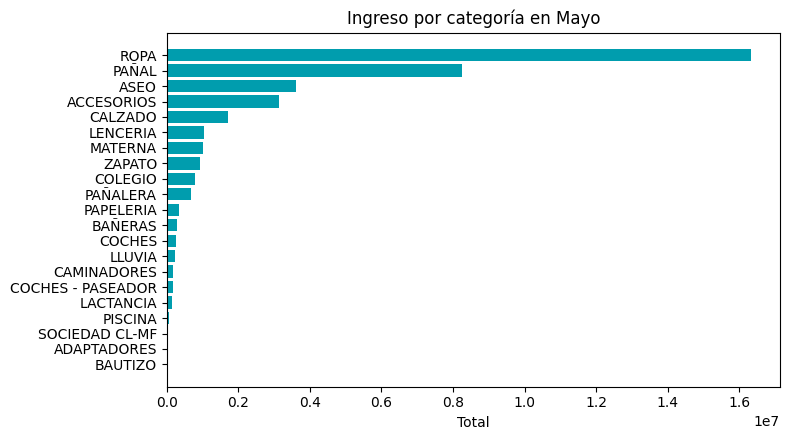

In [ ]:
figura_mayo, eje_mayo = plt.subplots(figsize=(8, 4.5))
eje_mayo.barh(ingreso_categoria_mayo.index, ingreso_categoria_mayo.values, color='#009DAE')
eje_mayo.set_title('Ingreso por categoría en Mayo')
eje_mayo.set_xlabel('Total')
plt.tight_layout()
plt.show()

##Analisis de ventas por Horas
### A continuación vamos a generar un gráfico que nos permite tener en una sola vista las ventas de los tres meses y las horas con mayor afluencia.


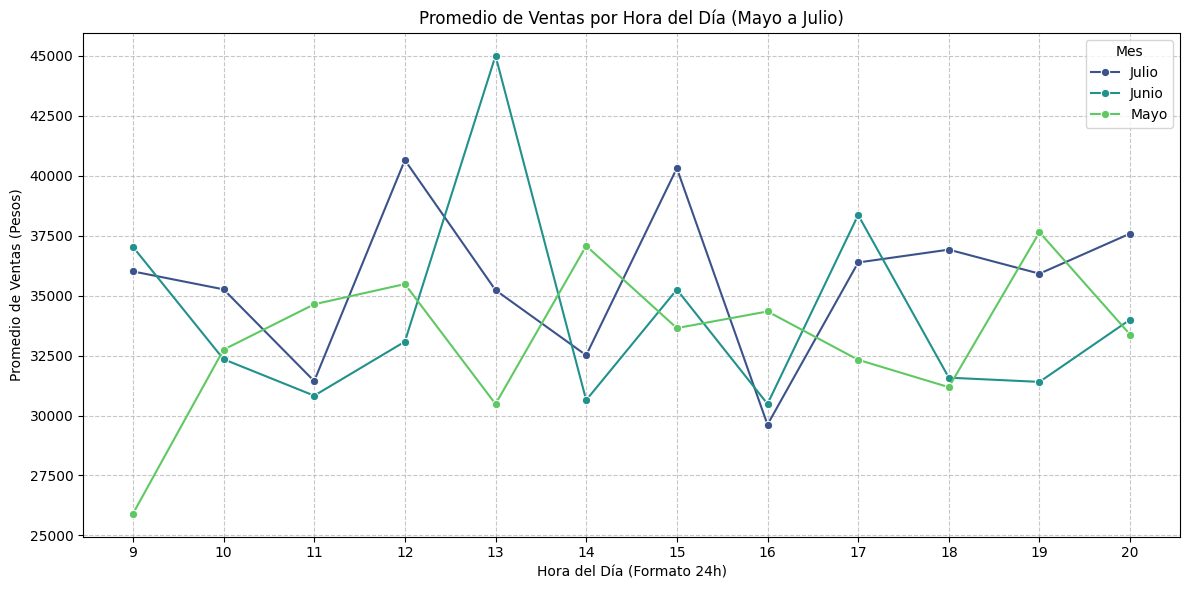

In [104]:
# Gráfico Consolidado de Ventas
graf = data.dropna(subset=['hora_del_dia', 'total', 'mes'])

if graf.empty:
    print("No hay registros con hora válida para graficar.")
else:
    # 'errorbar' existe desde seaborn 0.12; en versiones previas el parámetro es 'ci'
    kw = ({'errorbar': None} if tuple(int(x) for x in sns.__version__.split('.')[:2]) >= (0, 12)
          else {'ci': None})

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=graf, x='hora_del_dia', y='total', hue='mes',
                 marker='o', palette='viridis', **kw)

    horas = sorted(graf['hora_del_dia'].unique())
    plt.xticks(range(int(min(horas)), int(max(horas)) + 1))
    plt.title('Promedio de Ventas por Hora del Día (Mayo a Julio)')
    plt.xlabel('Hora del Día (Formato 24h)')
    plt.ylabel('Promedio de Ventas (Pesos)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Mes')
    plt.tight_layout()
    plt.show()

En el anterior gráfico podemos observar el comportamiento de ventas según la hora del día, siendo la 1pm la hora que mayor ventas hubo en el mes de mayo 2pm y 7pm, junio a la 1pm y 5pm en julio a las 12 y 3 pm

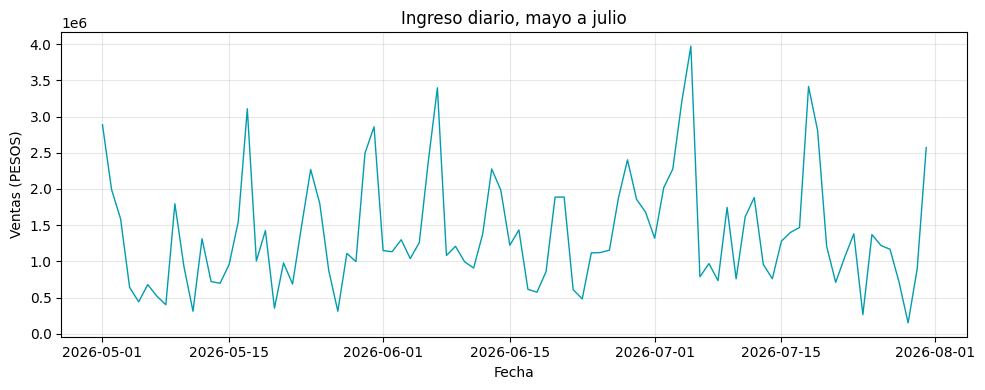

In [106]:
ingreso_dia = data.groupby('fecha')['total'].sum()
ingreso_dia.head()

figura, eje = plt.subplots(figsize=(10, 4))
eje.plot(ingreso_dia.index, ingreso_dia.values, linewidth=1, color='#009DAE')
eje.set_title('Ingreso diario, mayo a julio')
eje.set_xlabel('Fecha')
eje.set_ylabel('Ventas (PESOS)')
eje.grid(alpha=0.3)
plt.tight_layout()
plt.show()

En el anterior grafico se observa que los días de maor venta son días de quincena

## Histograma ventas por hora

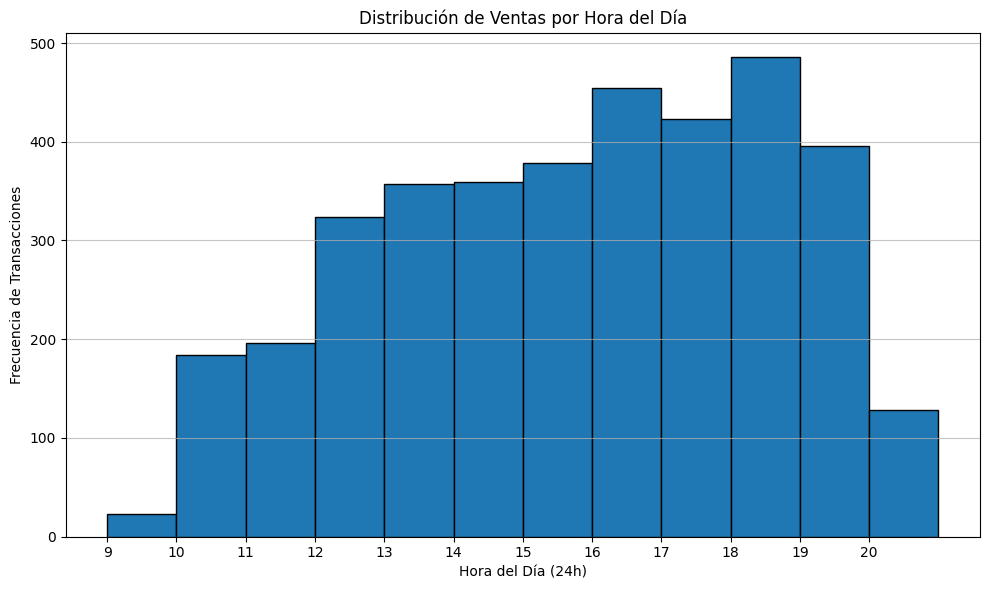

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(data['hora_del_dia'], bins=range(int(data['hora_del_dia'].min()), int(data['hora_del_dia'].max()) + 2), edgecolor='black')
plt.title('Distribución de Ventas por Hora del Día')
plt.xlabel('Hora del Día (24h)')
plt.ylabel('Frecuencia de Transacciones')
plt.xticks(range(int(data['hora_del_dia'].min()), int(data['hora_del_dia'].max()) + 1))
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

De acuerdo con el histograma anterior, se observa que mayor cantidad de transacciones se realiza, es entre las 4 y las 7 de la noche.

#CONCLUSIONES FINALES
1. El análisis del comportamiento de las ventas permite identificar que el periodo de mayor demanda se concentra principalmente entre las 12:00 p. m. y las 8:00 p. m., especialmente durante los días de quincena, cuando se presenta un incremento significativo en el flujo de clientes y en el volumen de ventas.
Por lo anterior, se recomienda disponer de una mayor cantidad de personal durante esta franja horaria, con el fin de atender oportunamente la demanda y
reducir los tiempos de espera.

2. Se recomienda tener una fuerza de ventas en estas fechas y horas de mayor demanda de: 4 personas sugiriendo los siguientes turnos y horarios.

*   Apertura: 1 Persona de 9am a 5pm
*   Intermedio: 1 Persona de 11am a 7pm
*   Cierre: 2 personas de 12m a 8pm







3. Las ventas presentan un mayor comportamiento durante los fines de semana posteriores a las fechas de quincena, periodo en el que se evidencia un incremento en la demanda y en el flujo de clientes.

